# 📊 Análisis Integral ClickaClick — Pre vs Post 
## Machine Learning aplicado a encuestas de adultos mayores
**Encuesta inicial (152 respuestas)** vs **Encuesta final post-ClickaClick (149 respuestas)**

Este notebook analiza el impacto de ClickaClick en la confianza tecnológica, el estrés digital y la autonomía de adultos mayores usando clustering, clasificación y visualizaciones interactivas.

## 1. Importar Librerías y Configuración

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_auc_score, roc_curve)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import chi2_contingency

# Colores ClickaClick
PURPLE  = "#5b3f86"
VIOLET  = "#8b6db5"
LAVEND  = "#c4aadf"
PINK    = "#e91e8c"
GOLD    = "#f5a623"
GREEN   = "#27ae60"
RED     = "#e74c3c"
BLUE    = "#3498db"

CC_PALETTE = [PURPLE, PINK, GOLD, GREEN, BLUE, RED, VIOLET, LAVEND, "#2ecc71", "#e67e22"]

# Estilo global
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#fafafa",
    "axes.edgecolor":    "#dddddd",
    "axes.grid":         True,
    "grid.alpha":        0.4,
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)

BASE = Path(".")
EXCEL1 = BASE / "Encuesta Sobre el Uso del Celular (respuestas) (1).xlsx"
EXCEL2 = BASE / "Encuesta Sobre el Uso del Celular Final (respuestas).xlsx"

print("✅ Librerías cargadas correctamente")
print(f"   Encuesta inicial : {EXCEL1.name}")
print(f"   Encuesta final   : {EXCEL2.name}")

✅ Librerías cargadas correctamente
   Encuesta inicial : Encuesta Sobre el Uso del Celular (respuestas) (1).xlsx
   Encuesta final   : Encuesta Sobre el Uso del Celular Final (respuestas).xlsx


## 2. Carga y Limpieza de Datos

In [2]:
# ── Cargar Excel ──────────────────────────────────────────────────────────────
df1_raw = pd.read_excel(EXCEL1)
df2_raw = pd.read_excel(EXCEL2)

# ── Renombrar columnas ────────────────────────────────────────────────────────
# Encuesta INICIAL
df1 = df1_raw.copy()
df1.columns = [
    "timestamp", "edad", "celular", "cuando_problema",
    "confianza", "estres", "usos_celular",
    "metodo_aprendizaje", "usaria_web"
]
df1["encuesta"] = "Inicial"
df1["momento"]  = "PRE"

# Encuesta FINAL (post-ClickaClick)
df2 = df2_raw.copy()
df2.columns = [
    "timestamp", "edad", "celular", "confianza",
    "estres", "usos_celular", "uso_clickaclick",
    "cuando_problema", "formato_util",
    "recomendaria", "tema_sugerido"
]
df2["encuesta"] = "Final"
df2["momento"]  = "POST"
df2["usaria_web"] = "Sí"  # ya la usaron → implícito

# ── Estandarizar valores ──────────────────────────────────────────────────────
EDAD_ORDER     = ["60 - 64 años", "65 - 69 años", "70 - 74 años", "75 años a más"]
CONF_ORDER     = ["Poco confiado", "Medianamente confiado", "Confiado", "Muy Confiado"]
ESTRES_ORDER   = ["Alto (me pongo muy nervioso(a) o evito usarlo)",
                  "Medio (a veces me siento nervioso(a))",
                  "Bajo (me siento tranquilo(a) al usarlo)"]

# Mapas numéricos ordinales
CONF_MAP  = {v: i for i, v in enumerate(CONF_ORDER)}    # 0=Poco → 3=Muy
ESTRES_MAP = {
    "Alto (me pongo muy nervioso(a) o evito usarlo)":  0,
    "Medio (a veces me siento nervioso(a))":           1,
    "Bajo (me siento tranquilo(a) al usarlo)":         2,
}
EDAD_MAP = {v: i for i, v in enumerate(EDAD_ORDER)}

for df in [df1, df2]:
    df["confianza_num"] = df["confianza"].map(CONF_MAP)
    df["estres_num"]    = df["estres"].map(ESTRES_MAP)
    df["edad_num"]      = df["edad"].str.strip().map(EDAD_MAP)

# ── Multi-hot: usos del celular ───────────────────────────────────────────────
USOS_POSIBLES = [
    "Llamar por teléfono", "Usar Whatsapp", "Ver fotos o videos",
    "Buscar información",  "Redes Sociales", "No lo uso casi nunca"
]

def multi_hot(series, options):
    rows = []
    for val in series:
        val = str(val) if pd.notna(val) else ""
        row = {opt: int(opt.lower() in val.lower()) for opt in options}
        rows.append(row)
    return pd.DataFrame(rows, index=series.index)

for df in [df1, df2]:
    mh = multi_hot(df["usos_celular"], USOS_POSIBLES)
    for col in mh.columns:
        df[f"uso_{col[:4].strip()}"] = mh[col]

# ── Combinar ambas encuestas ──────────────────────────────────────────────────
common_cols = ["timestamp","edad","edad_num","celular","confianza","confianza_num",
               "estres","estres_num","usos_celular","cuando_problema",
               "encuesta","momento",
               "uso_Llam","uso_Usar","uso_Ver ","uso_Busc","uso_Rede","uso_No l"]

df_all = pd.concat([df1, df2], ignore_index=True)

print(f"Encuesta INICIAL : {len(df1):>3} filas")
print(f"Encuesta FINAL   : {len(df2):>3} filas")
print(f"Total combinado  : {len(df_all):>3} filas\n")
df_all[["edad","confianza","estres","momento"]].sample(5)

Encuesta INICIAL : 152 filas
Encuesta FINAL   : 149 filas
Total combinado  : 301 filas



,edad,confianza,estres,momento
80,70 - 74 años,Medianamente confiado,Bajo (me siento tranquilo(a) al usarlo),PRE
286,70 - 74 años,Medianamente confiado,Bajo (me siento tranquilo(a) al usarlo),POST
49,75 años a más,Medianamente confiado,Alto (me pongo muy nervioso(a) o evito usarlo),PRE
41,65 - 69 años,Poco confiado,Medio (a veces me siento nervioso(a)),PRE
199,75 años a más,Medianamente confiado,Bajo (me siento tranquilo(a) al usarlo),POST


## 3. Análisis Exploratorio (EDA) — Visualizaciones Comparativas PRE vs POST

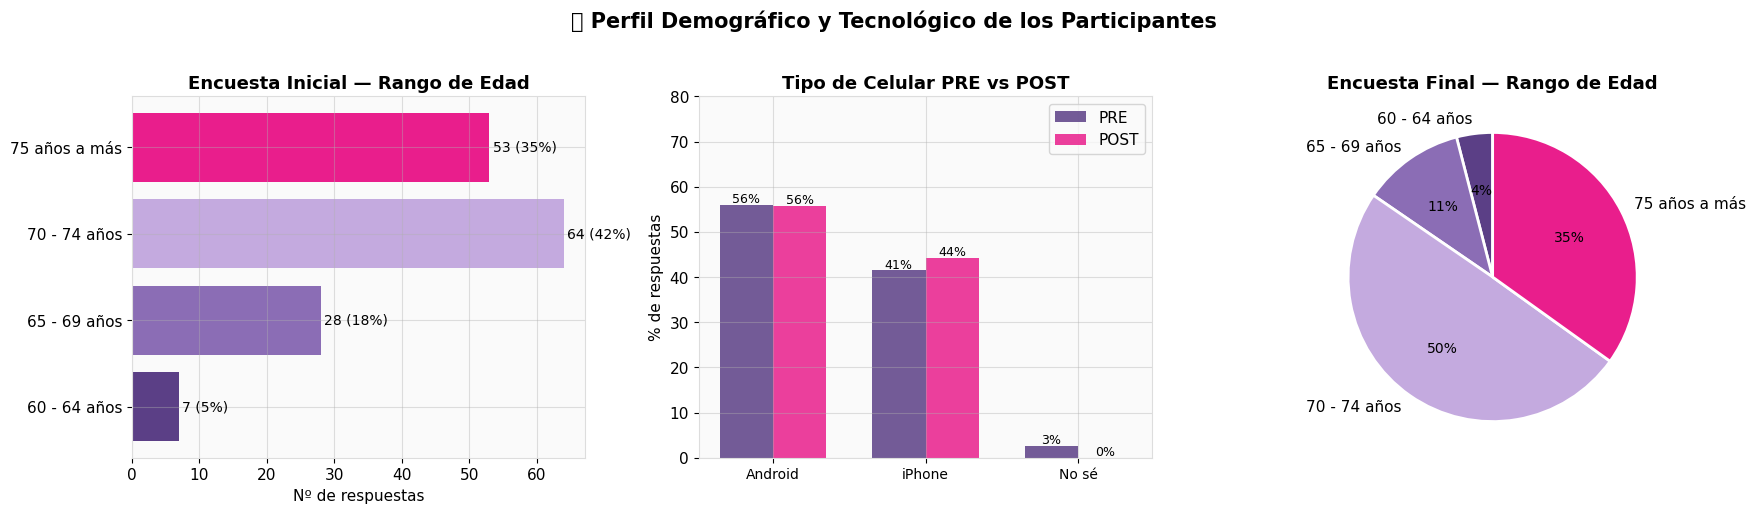

Guardado: graf_01_demografico.png


In [3]:
# ════════════════════════════════════════════════════════
#  GRÁFICO 1 — Distribución de Edad y Celular
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("👥 Perfil Demográfico y Tecnológico de los Participantes", fontsize=15, fontweight="bold", y=1.02)

# Edad — encuesta inicial
edad_counts = df1["edad"].value_counts().reindex(EDAD_ORDER, fill_value=0)
axes[0].barh(EDAD_ORDER, edad_counts.values, color=[PURPLE, VIOLET, LAVEND, PINK])
axes[0].set_title("Encuesta Inicial — Rango de Edad")
axes[0].set_xlabel("Nº de respuestas")
for i, v in enumerate(edad_counts):
    axes[0].text(v + 0.5, i, f"{v} ({100*v/len(df1):.0f}%)", va="center", fontsize=10)

# Celular — comparación
cel_pre  = df1["celular"].value_counts(normalize=True) * 100
cel_post = df2["celular"].value_counts(normalize=True) * 100
tipos = ["Android", "Iphone", "No estoy seguro / No lo sé"]
x = np.arange(len(tipos))
w = 0.35
b1 = axes[1].bar(x - w/2, [cel_pre.get(t,0) for t in tipos],  w, label="PRE",  color=PURPLE, alpha=0.85)
b2 = axes[1].bar(x + w/2, [cel_post.get(t,0) for t in tipos], w, label="POST", color=PINK,   alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(["Android","iPhone","No sé"], fontsize=10)
axes[1].set_ylabel("% de respuestas"); axes[1].set_title("Tipo de Celular PRE vs POST")
axes[1].legend(); axes[1].set_ylim(0, 80)
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{bar.get_height():.0f}%", ha="center", fontsize=9)

# Edad POST
edad_post = df2["edad"].value_counts().reindex(EDAD_ORDER, fill_value=0)
wedges, texts, autotexts = axes[2].pie(
    edad_post, labels=EDAD_ORDER, autopct="%1.0f%%",
    colors=[PURPLE, VIOLET, LAVEND, PINK], startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2})
[t.set_fontsize(10) for t in autotexts]
axes[2].set_title("Encuesta Final — Rango de Edad")

plt.tight_layout()
plt.savefig("graf_01_demografico.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: graf_01_demografico.png")

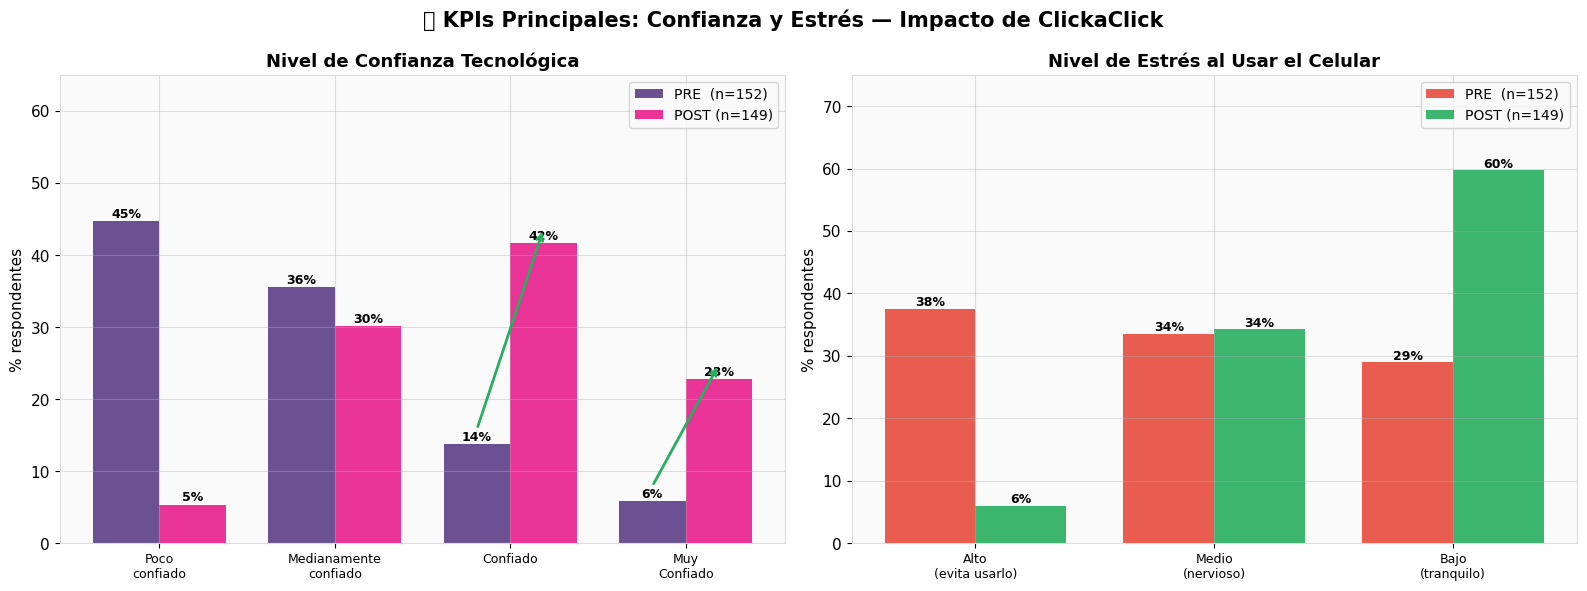

📈 IMPACTO DE CLICKACLICK
   Confianza media PRE  : 0.81/3  → POST: 1.82/3  (+1.01)
   Estrés medio   PRE   : 0.91/2  → POST: 1.54/2  (+0.62)
   % 'Confiado'+'Muy Confiado' PRE: 20%  →  POST: 64%


In [6]:
# ════════════════════════════════════════════════════════
#  GRÁFICO 2 — KPI Principal: Confianza y Estrés PRE vs POST
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("🎯 KPIs Principales: Confianza y Estrés — Impacto de ClickaClick", fontsize=15, fontweight="bold")

# Confianza
conf_pre  = df1["confianza"].value_counts(normalize=True).reindex(CONF_ORDER, fill_value=0) * 100
conf_post = df2["confianza"].value_counts(normalize=True).reindex(CONF_ORDER, fill_value=0) * 100
x = np.arange(len(CONF_ORDER))
w = 0.38
b1 = axes[0].bar(x - w/2, conf_pre.values,  w, color=PURPLE, alpha=0.9, label="PRE  (n=152)")
b2 = axes[0].bar(x + w/2, conf_post.values, w, color=PINK,   alpha=0.9, label="POST (n=149)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Poco\nconfiado","Medianamente\nconfiado","Confiado","Muy\nConfiado"], fontsize=9)
axes[0].set_ylabel("% respondentes")
axes[0].set_title("Nivel de Confianza Tecnológica")
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 65)
for bar in list(b1) + list(b2):
    if bar.get_height() > 1:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f"{bar.get_height():.0f}%", ha="center", fontsize=9, fontweight="bold")
# Flechas de mejora
for i in [2, 3]:  # Confiado + Muy Confiado
    axes[0].annotate("", xy=(i+w/2, conf_post.values[i]+2),
                     xytext=(i-w/2, conf_pre.values[i]+2),
                     arrowprops=dict(arrowstyle="->", color=GREEN, lw=2))

# Estrés
ESTRES_LABELS = ["Alto\n(evita usarlo)", "Medio\n(nervioso)", "Bajo\n(tranquilo)"]
estres_pre  = df1["estres"].value_counts(normalize=True).reindex(ESTRES_ORDER, fill_value=0) * 100
estres_post = df2["estres"].value_counts(normalize=True).reindex(ESTRES_ORDER, fill_value=0) * 100
x_estres = np.arange(len(ESTRES_ORDER))
b3 = axes[1].bar(x_estres - w/2, estres_pre.values,  w, color=RED,   alpha=0.9, label="PRE  (n=152)")
b4 = axes[1].bar(x_estres + w/2, estres_post.values, w, color=GREEN, alpha=0.9, label="POST (n=149)")
axes[1].set_xticks(x_estres)
axes[1].set_xticklabels(ESTRES_LABELS, fontsize=9)
axes[1].set_ylabel("% respondentes")
axes[1].set_title("Nivel de Estrés al Usar el Celular")
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 75)
for bar in list(b3) + list(b4):
    if bar.get_height() > 1:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f"{bar.get_height():.0f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("graf_02_confianza_estres.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadísticas de mejora
print("📈 IMPACTO DE CLICKACLICK")
print(f"   Confianza media PRE  : {df1['confianza_num'].mean():.2f}/3  → POST: {df2['confianza_num'].mean():.2f}/3  (+{df2['confianza_num'].mean()-df1['confianza_num'].mean():.2f})")
print(f"   Estrés medio   PRE   : {df1['estres_num'].mean():.2f}/2  → POST: {df2['estres_num'].mean():.2f}/2  (+{df2['estres_num'].mean()-df1['estres_num'].mean():.2f})")
conf_alto_pre  = (df1["confianza"].isin(["Confiado","Muy Confiado"])).mean()*100
conf_alto_post = (df2["confianza"].isin(["Confiado","Muy Confiado"])).mean()*100
print(f"   % 'Confiado'+'Muy Confiado' PRE: {conf_alto_pre:.0f}%  →  POST: {conf_alto_post:.0f}%")

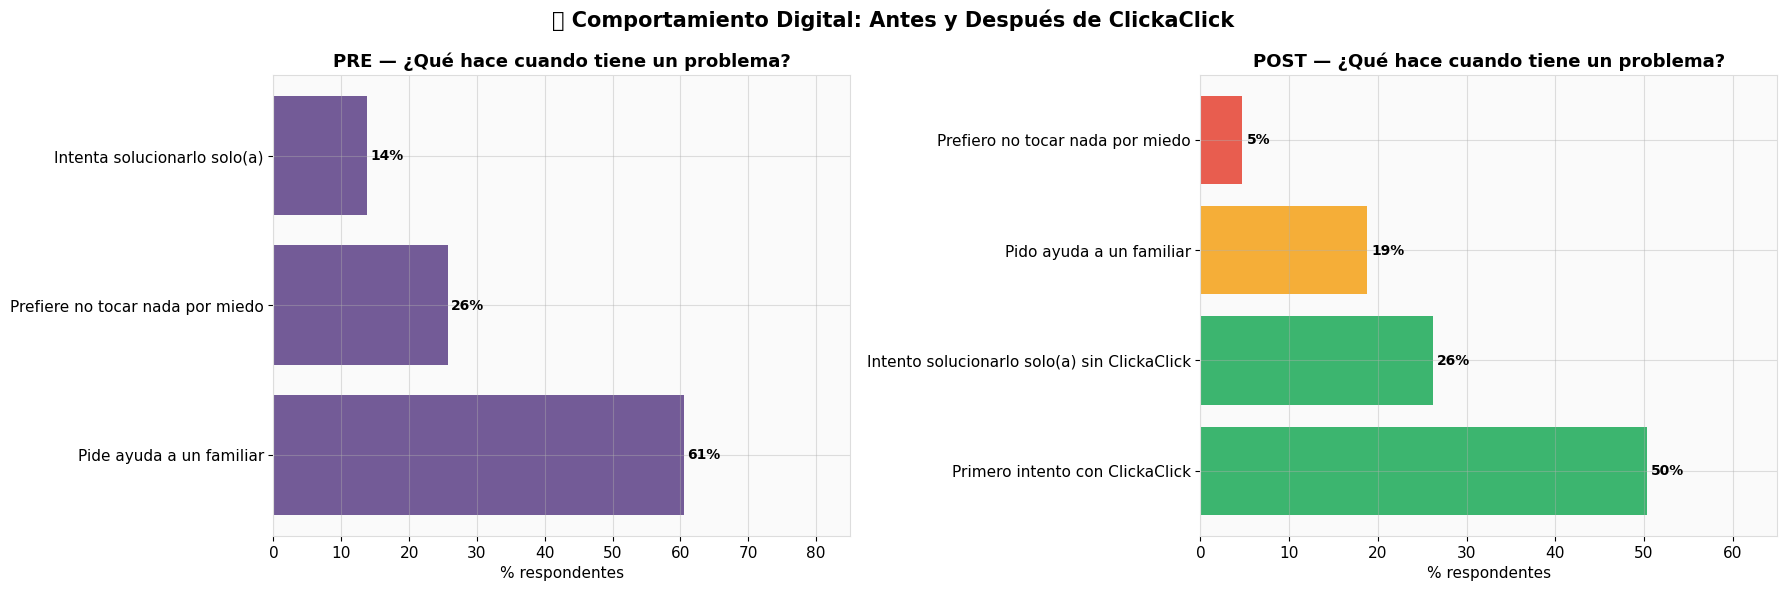

🔑 Dato clave: 77% ahora intenta primero con ClickaClick
   (vs 61% que antes pedía ayuda a un familiar)


In [7]:
# ════════════════════════════════════════════════════════
#  GRÁFICO 3 — Comportamiento ante problemas + Uso del celular
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("📱 Comportamiento Digital: Antes y Después de ClickaClick", fontsize=15, fontweight="bold")

# Comportamiento ante problemas
prob_labels_pre = [
    "Pide ayuda a un familiar", "Prefiere no tocar nada por miedo",
    "Intenta solucionarlo solo(a)", "Pide ayuda a técnico / tienda"
]
prob_pre  = df1["cuando_problema"].value_counts(normalize=True)*100

DESPUES_ORDER = [
    "Primero intento con ClickaClick",
    "Intento solucionarlo solo(a) sin ClickaClick",
    "Pido ayuda a un familiar",
    "Prefiero no tocar nada por miedo"
]
prob_post = df2["cuando_problema"].value_counts(normalize=True)*100

# PRE
colors_pre = [PURPLE if "familiar" in l else RED if "miedo" in l else VIOLET for l in prob_pre.index]
axes[0].barh(prob_pre.index, prob_pre.values, color=PURPLE, alpha=0.85)
axes[0].set_title("PRE — ¿Qué hace cuando tiene un problema?")
axes[0].set_xlabel("% respondentes")
for i, v in enumerate(prob_pre):
    axes[0].text(v+0.5, i, f"{v:.0f}%", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlim(0, 85)

# POST  
post_colors = [GREEN if "ClickaClick" in str(l) else BLUE if "solo" in str(l)
               else GOLD if "familiar" in str(l) else RED for l in prob_post.index]
axes[1].barh(prob_post.index, prob_post.values, color=post_colors, alpha=0.9)
axes[1].set_title("POST — ¿Qué hace cuando tiene un problema?")
axes[1].set_xlabel("% respondentes")
for i, v in enumerate(prob_post):
    axes[1].text(v+0.5, i, f"{v:.0f}%", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlim(0, 65)

plt.tight_layout()
plt.savefig("graf_03_comportamiento.png", dpi=150, bbox_inches="tight")
plt.show()

# Intentar con ClickaClick primero
cc_primero = (df2["cuando_problema"].str.contains("ClickaClick", na=False)).mean()*100
familiar_pre = (df1["cuando_problema"] == "Pide ayuda a un familiar").mean()*100
print(f"🔑 Dato clave: {cc_primero:.0f}% ahora intenta primero con ClickaClick")
print(f"   (vs {familiar_pre:.0f}% que antes pedía ayuda a un familiar)")

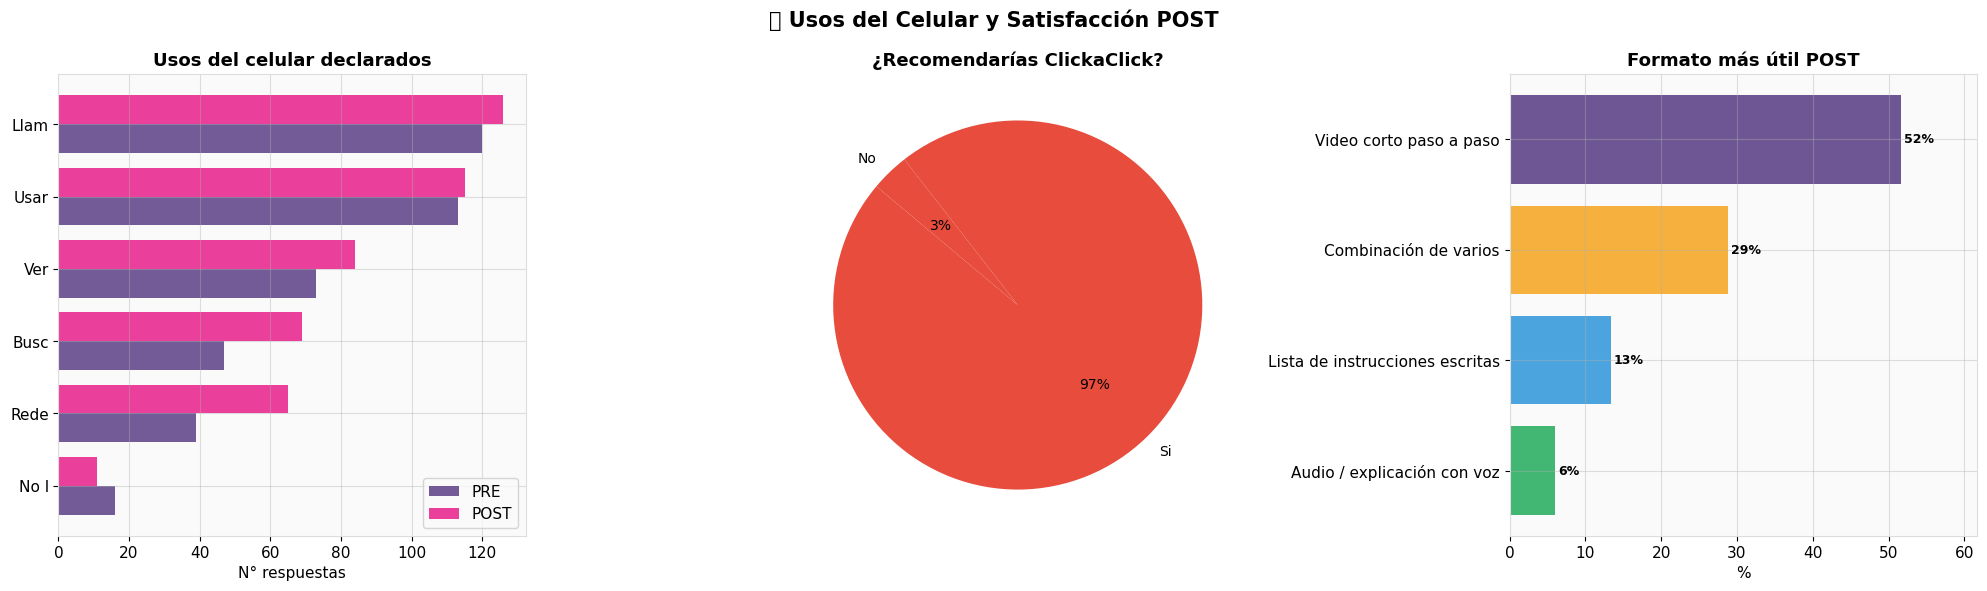

✅ 97% recomendaría ClickaClick


In [9]:
# ════════════════════════════════════════════════════════
#  GRÁFICO 4 — Usos del celular PRE vs POST + métricas POST exclusivas
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("📊 Usos del Celular y Satisfacción POST", fontsize=15, fontweight="bold")

# Usos del celular frecuencias
# (solo columnas uso_ numéricas para evitar mezclar strings como 'uso_clickaclick')
uso_cols = [
    c for c in df_all.columns
    if c.startswith("uso_") and pd.api.types.is_numeric_dtype(df_all[c])
]
uso_pre  = df_all[df_all["momento"]=="PRE"][uso_cols].sum().sort_values(ascending=True)
uso_post = df_all[df_all["momento"]=="POST"][uso_cols].sum().sort_values(ascending=True)
labels = [c.replace("uso_","").strip() for c in uso_pre.index]

x = np.arange(len(labels))
w = 0.4
axes[0].barh(x - w/2, uso_pre.values,  w, label="PRE",  color=PURPLE, alpha=0.85)
axes[0].barh(x + w/2, uso_post.values, w, label="POST", color=PINK,   alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(labels)
axes[0].set_title("Usos del celular declarados")
axes[0].set_xlabel("N° respuestas")
axes[0].legend()

# recomendaria
rec = df2["recomendaria"].value_counts()
pie_colors = [GREEN if "Sí" in str(k) or "sí" in str(k) else GOLD if "Tal" in str(k) else RED for k in rec.index]
axes[1].pie(rec.values, labels=rec.index, autopct="%1.0f%%",
            colors=pie_colors, startangle=140,
            textprops={"fontsize": 10})
axes[1].set_title("¿Recomendarías ClickaClick?")

# formato_util
fmt = df2["formato_util"].value_counts(normalize=True)*100
fmt = fmt.sort_values()
axes[2].barh(fmt.index, fmt.values,
             color=[GREEN, BLUE, GOLD, PURPLE, PINK][:len(fmt)], alpha=0.88)
axes[2].set_title("Formato más útil POST")
axes[2].set_xlabel("%")
for i, v in enumerate(fmt):
    axes[2].text(v+0.3, i, f"{v:.0f}%", va="center", fontsize=9, fontweight="bold")
axes[2].set_xlim(0, fmt.max()+10)

plt.tight_layout()
plt.savefig("graf_04_usos_satisfaccion.png", dpi=150, bbox_inches="tight")
plt.show()

recomendaria_si = rec[rec.index.str.contains("Sí|sí|si", case=False, na=False)].sum() / rec.sum() * 100 if rec.index.str.contains("Sí|sí|si", case=False, na=False).any() else 0
print(f"✅ {recomendaria_si:.0f}% recomendaría ClickaClick")

## 4. Ingeniería de Características (Feature Engineering)

Creamos índices compuestos para capturar dimensiones latentes:
- **Autonomía Digital** = confianza + independencia ante problemas
- **Índice de Ansiedad Tecnológica** = inversamente proporcional al estrés
- **Diversidad de Uso** = cantidad de usos distintos del celular

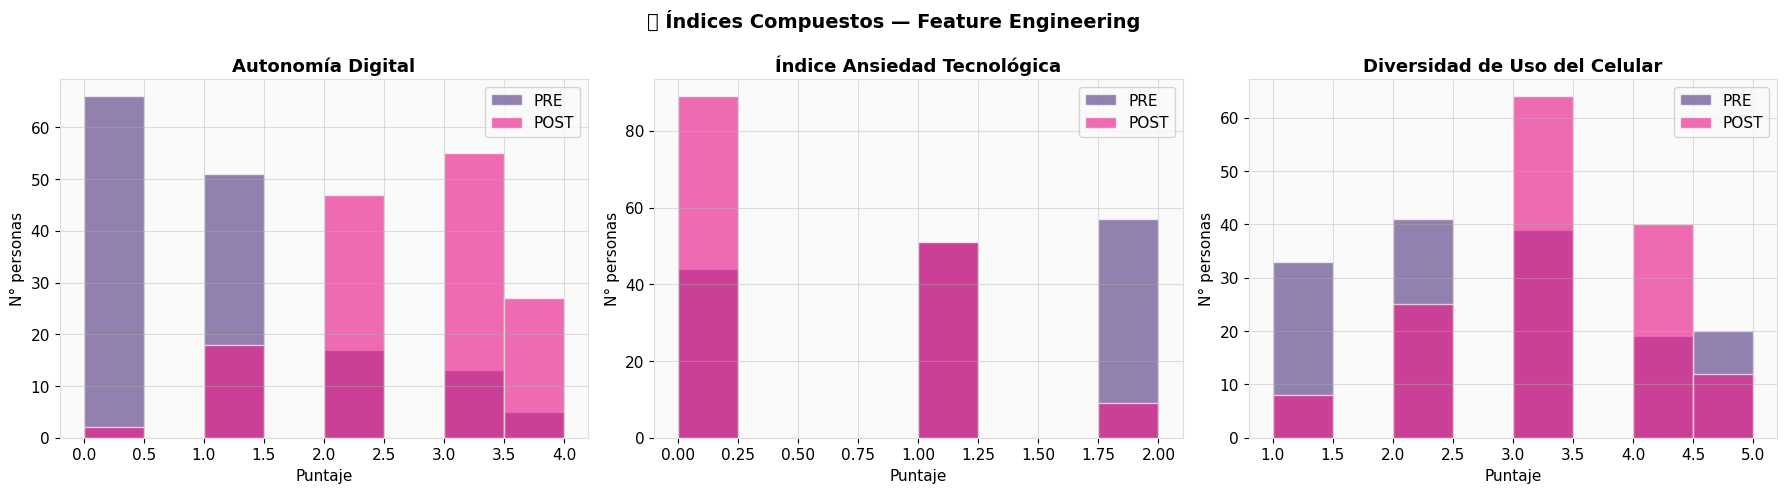


── Estadísticas de features por momento ──
         autonomia_score  ansiedad_tech  uso_diversity  madurez_digital
momento                                                                
POST                2.58           0.46           3.15             4.75
PRE                 0.95           1.09           2.68             2.40


In [11]:
# ── Feature Engineering ──────────────────────────────────────────────────────
uso_cols = [
    c for c in df_all.columns
    if c.startswith("uso_") and pd.api.types.is_numeric_dtype(df_all[c])
]

# 1. Diversidad de uso del celular
df_all["uso_diversity"] = df_all[uso_cols].sum(axis=1)

# 2. Autonomía digital (0-4)
#    +1 si intenta solo o usa ClickaClick primero (no depende de otros)
autonomo_keywords = ["solo", "ClickaClick"]
df_all["es_autonomo"] = df_all["cuando_problema"].apply(
    lambda x: 1 if any(k in str(x) for k in autonomo_keywords) else 0
)
df_all["autonomia_score"] = df_all["confianza_num"].fillna(0) + df_all["es_autonomo"]

# 3. Índice de ansiedad tecnológica (mayor = más ansioso)
df_all["ansiedad_tech"] = 2 - df_all["estres_num"].fillna(1)

# 4. Score compuesto de madurez digital (0-7)
df_all["madurez_digital"] = (
    df_all["confianza_num"].fillna(0)          # 0-3
    + df_all["es_autonomo"]                     # 0-1
    + (2 - df_all["ansiedad_tech"].fillna(1))  # 0-2 (menos ansiedad = más madurez)
    + df_all["uso_diversity"] / df_all["uso_diversity"].max()  # 0-1 normalizado
)

# Visualización de features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("🔧 Índices Compuestos — Feature Engineering", fontsize=14, fontweight="bold")

for ax, (col, title, color) in zip(axes, [
    ("autonomia_score",  "Autonomía Digital", PURPLE),
    ("ansiedad_tech",    "Índice Ansiedad Tecnológica", RED),
    ("uso_diversity",    "Diversidad de Uso del Celular", BLUE),
]):
    for momento, ls in [("PRE", "--"), ("POST", "-")]:
        subset = df_all[df_all["momento"]==momento][col].dropna()
        subset.hist(ax=ax, bins=8, alpha=0.65, label=momento,
                    color=PURPLE if momento=="PRE" else PINK, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Puntaje")
    ax.set_ylabel("N° personas")
    ax.legend()

plt.tight_layout()
plt.savefig("graf_05_features.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumen estadístico de features
print("\n── Estadísticas de features por momento ──")
print(df_all.groupby("momento")[["autonomia_score","ansiedad_tech","uso_diversity","madurez_digital"]].mean().round(2))

## 5. Clustering — Segmentación de Usuarios (KMeans + PCA)

Aplicamos **KMeans** sobre los índices compuestos para encontrar perfiles latentes de adultos mayores. La **reducción dimensional con PCA** nos permite visualizar los clusters en 2D.

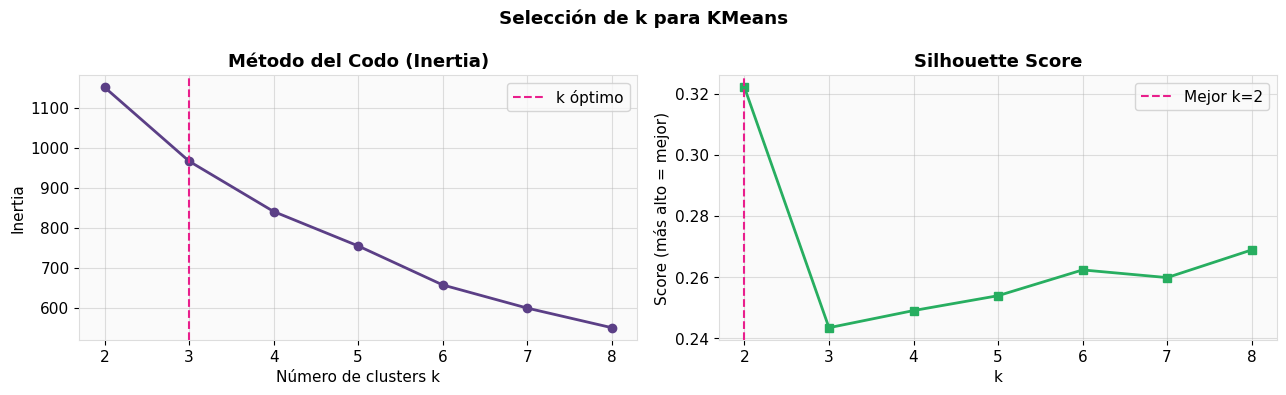

▶ k óptimo por silhouette: 2  (score=0.322)


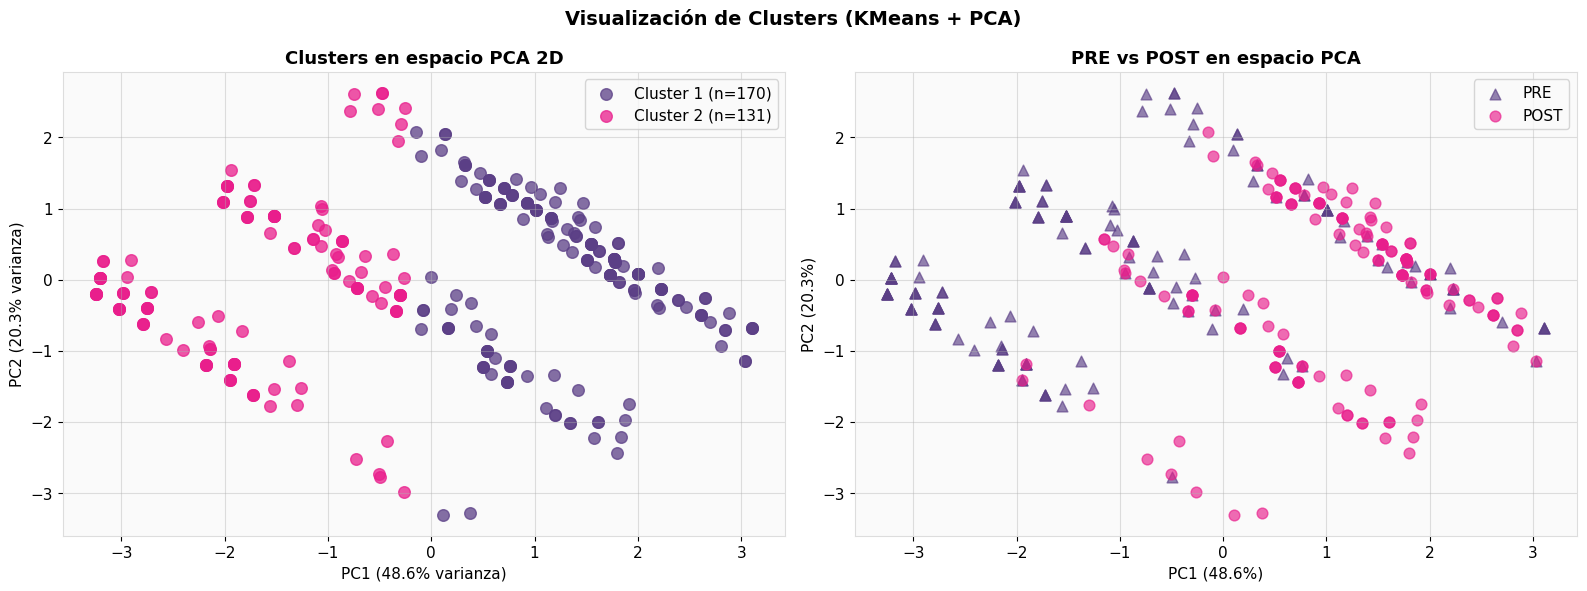


── Perfil promedio por cluster ──
         confianza_num  estres_num  edad_num  autonomia_score  ansiedad_tech  \
cluster                                                                        
0                 1.91        1.72      2.09             2.59           0.28   
1                 0.53        0.57      2.14             0.68           1.43   

         uso_diversity  
cluster                 
0                 3.28  
1                 2.45  

── Distribución PRE/POST por cluster ──
momento  POST  PRE
cluster           
0         128   42
1          21  110


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── Preparar features ────────────────────────────────────────────────────────
CLUSTER_FEATS = ["confianza_num", "estres_num", "edad_num",
                 "autonomia_score", "ansiedad_tech", "uso_diversity"]

df_clust = df_all[CLUSTER_FEATS].copy().dropna()
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# ── Método del codo + Silhouette ─────────────────────────────────────────────
inertias, sil_scores = [], []
K_RANGE = range(2, 9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inertias, "o-", color=PURPLE, lw=2)
axes[0].set_title("Método del Codo (Inertia)")
axes[0].set_xlabel("Número de clusters k")
axes[0].set_ylabel("Inertia")
axes[0].axvline(3, color=PINK, ls="--", label="k óptimo")
axes[0].legend()

axes[1].plot(list(K_RANGE), sil_scores, "s-", color=GREEN, lw=2)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score (más alto = mejor)")
best_k = list(K_RANGE)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color=PINK, ls="--", label=f"Mejor k={best_k}")
axes[1].legend()

plt.suptitle("Selección de k para KMeans", fontweight="bold")
plt.tight_layout()
plt.savefig("graf_06_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"▶ k óptimo por silhouette: {best_k}  (score={max(sil_scores):.3f})")

# ── Ajustar modelo final ─────────────────────────────────────────────────────
K_FINAL = best_k
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
labels   = km_final.fit_predict(X_scaled)
df_clust["cluster"] = labels
df_clust["momento"] = df_all.loc[df_clust.index, "momento"].values

# ── PCA 2D ───────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_clust["PC1"] = X_pca[:, 0]
df_clust["PC2"] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
CLUSTER_COLORS = [PURPLE, PINK, GREEN, GOLD, BLUE]

# Scatter por cluster
for c in range(K_FINAL):
    mask = df_clust["cluster"] == c
    axes[0].scatter(df_clust.loc[mask,"PC1"], df_clust.loc[mask,"PC2"],
                    color=CLUSTER_COLORS[c], alpha=0.75, s=70,
                    label=f"Cluster {c+1} (n={mask.sum()})")
axes[0].set_title("Clusters en espacio PCA 2D")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
axes[0].legend()

# Scatter por momento PRE/POST
for mom, marker, col in [("PRE", "^", PURPLE), ("POST", "o", PINK)]:
    mask = df_clust["momento"] == mom
    axes[1].scatter(df_clust.loc[mask,"PC1"], df_clust.loc[mask,"PC2"],
                    marker=marker, color=col, alpha=0.65, s=60, label=mom)
axes[1].set_title("PRE vs POST en espacio PCA")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].legend()

plt.suptitle("Visualización de Clusters (KMeans + PCA)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("graf_07_pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Perfiles de cluster ──────────────────────────────────────────────────────
print("\n── Perfil promedio por cluster ──")
perfil = df_clust.groupby("cluster")[CLUSTER_FEATS].mean().round(2)
print(perfil)
print("\n── Distribución PRE/POST por cluster ──")
print(pd.crosstab(df_clust["cluster"], df_clust["momento"]))

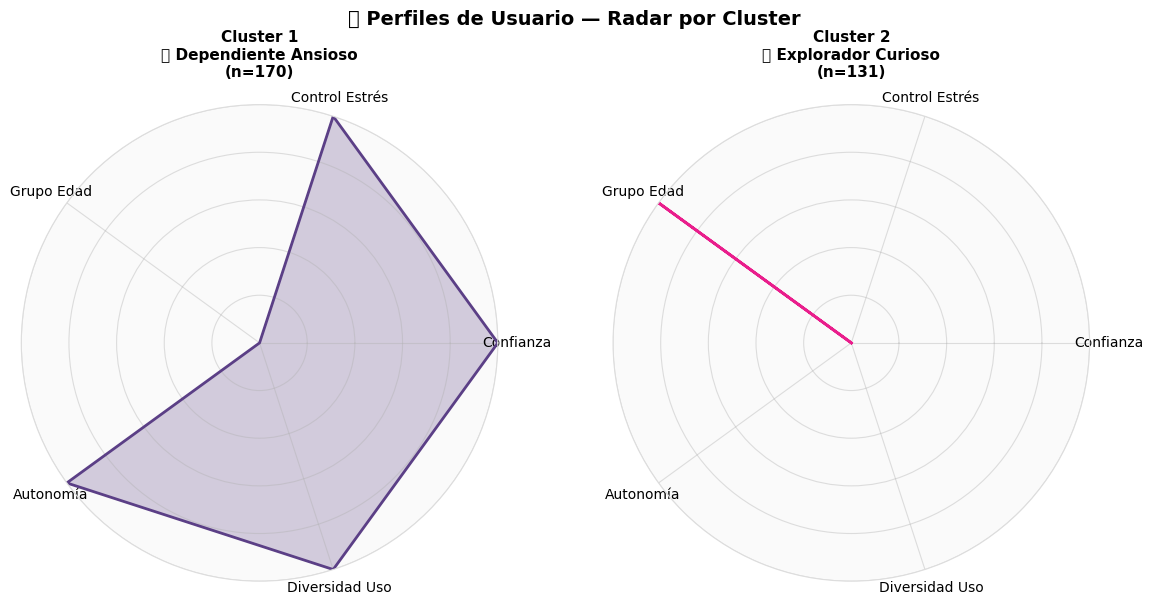

In [13]:
# ── Radar Chart — Personas por Cluster ───────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

RADAR_FEATS  = ["confianza_num", "estres_num", "edad_num",
                "autonomia_score", "uso_diversity"]
RADAR_LABELS = ["Confianza", "Control Estrés",
                "Grupo Edad", "Autonomía", "Diversidad Uso"]

cat_means = df_clust.groupby("cluster")[RADAR_FEATS].mean()
# Normalizar 0-1
for col in RADAR_FEATS:
    r = cat_means[col].max() - cat_means[col].min()
    cat_means[col] = (cat_means[col] - cat_means[col].min()) / (r if r else 1)

N = len(RADAR_FEATS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_FINAL, figsize=(6*K_FINAL, 6),
                         subplot_kw=dict(polar=True))
if K_FINAL == 1:
    axes = [axes]

PERSONA_NAMES = ["👴 Dependiente Ansioso",
                 "📱 Explorador Curioso",
                 "🏆 Autónomo Digital",
                 "🤝 Asistido Tranquilo"]

for i, ax in enumerate(axes):
    if i >= K_FINAL: break
    vals = cat_means.loc[i].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=CLUSTER_COLORS[i], lw=2)
    ax.fill(angles, vals, color=CLUSTER_COLORS[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=10)
    ax.set_ylim(0, 1)
    n_c = (df_clust["cluster"]==i).sum()
    ax.set_title(f"Cluster {i+1}\n{PERSONA_NAMES[i] if i < len(PERSONA_NAMES) else ''}\n(n={n_c})",
                 fontweight="bold", fontsize=11, pad=20)
    ax.set_yticklabels([])

plt.suptitle("🎯 Perfiles de Usuario — Radar por Cluster", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graf_08_radar_personas.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Clasificación — ¿Qué predice que alguien recomiende ClickaClick?

Entrenamos tres clasificadores (**Random Forest**, **Logistic Regression**, **Gradient Boosting**) sobre datos POST para predecir `recomendaria`. Comparamos curvas ROC, matrices de confusión e importancia de variables.

Dataset clasificación: 149 muestras, clases: [  5 144]
Distribución: 97% recomienda ClickaClick

── Cross-Validation (5-fold, AUC) ──
  Random Forest            : 0.547 ± 0.218
  Logistic Regression      : 0.561 ± 0.168
  Gradient Boosting        : 0.380 ± 0.268


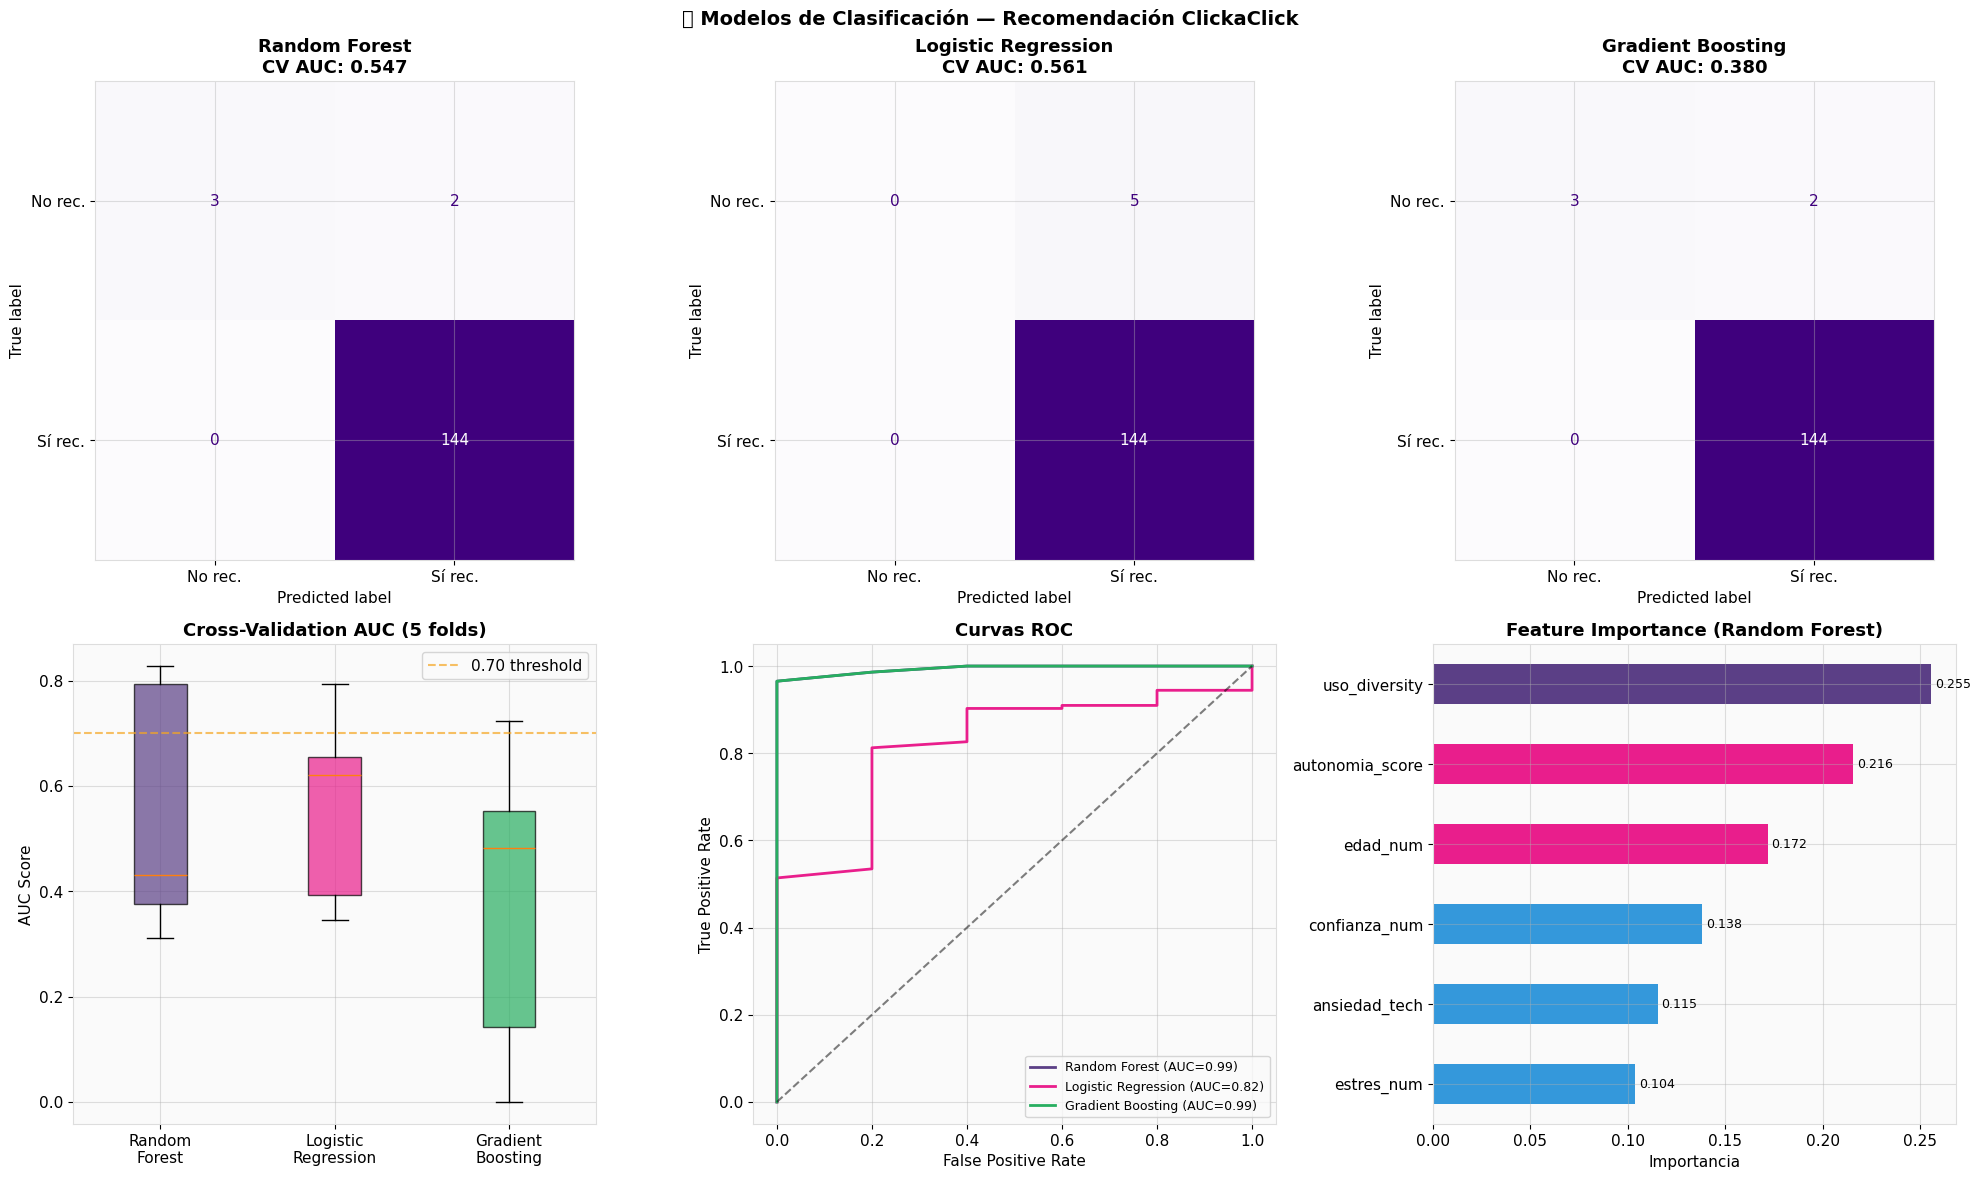

In [18]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc, classification_report)
from sklearn.preprocessing import LabelEncoder
import warnings; warnings.filterwarnings("ignore")

# ── Dataset POST con target ──────────────────────────────────────────────────
df_post = df2.copy()
df_post["autonomia_score"] = (df_post["confianza_num"].fillna(0) +
    df_post["cuando_problema"].apply(
        lambda x: 1 if any(k in str(x) for k in ["solo", "ClickaClick"]) else 0
    ))
df_post["ansiedad_tech"]  = 2 - pd.to_numeric(df_post["estres_num"], errors="coerce").fillna(1)

# Solo columnas de uso numéricas (excluye texto como 'uso_clickaclick')
uso_cols_post = [
    c for c in df_post.columns
    if c.startswith("uso_") and c != "uso_clickaclick"
]
df_post["uso_diversity"] = df_post[uso_cols_post].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)

# Target binario: ¿Recomienda? (Sí=1 / resto=0)
df_post["target"] = df_post["recomendaria"].apply(
    lambda x: 1 if any(k in str(x).lower() for k in ["sí","si"]) else 0
)

FEAT_COLS = ["confianza_num","estres_num","edad_num",
             "autonomia_score","ansiedad_tech","uso_diversity"]
df_ml = df_post[FEAT_COLS + ["target"]].dropna()
X = df_ml[FEAT_COLS].values
y = df_ml["target"].values

if len(np.unique(y)) < 2:
    print("⚠️  Con estos datos sólo hay una clase — extendemos target con 'Tal vez'=1")
    df_post["target"] = df_post["recomendaria"].apply(
        lambda x: 1 if any(k in str(x).lower() for k in ["sí","si","tal"]) else 0
    )
    df_ml = df_post[FEAT_COLS + ["target"]].dropna()
    X = df_ml[FEAT_COLS].values
    y = df_ml["target"].values

print(f"Dataset clasificación: {X.shape[0]} muestras, clases: {np.bincount(y)}")
print(f"Distribución: {y.mean()*100:.0f}% recomienda ClickaClick")

# ── Modelos ──────────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv_scores = {}
print("\n── Cross-Validation (5-fold, AUC) ──")
for name, model in models.items():
    try:
        scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
        cv_scores[name] = scores
        print(f"  {name:<25}: {scores.mean():.3f} ± {scores.std():.3f}")
    except Exception as e:
        print(f"  {name}: error ({e})")
        cv_scores[name] = np.array([0.5]*5)

# ── Entrenar en todos los datos ───────────────────────────────────────────────
for name, model in models.items():
    model.fit(X, y)

# ── Visualizaciones ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("🤖 Modelos de Clasificación — Recomendación ClickaClick",
             fontsize=14, fontweight="bold")

COLORS_MODEL = [PURPLE, PINK, GREEN]

# Row 0: Confusion matrices
for (name, model), color, ax in zip(models.items(), COLORS_MODEL, axes[0]):
    cm = confusion_matrix(y, model.predict(X))
    disp = ConfusionMatrixDisplay(cm, display_labels=["No rec.","Sí rec."])
    disp.plot(ax=ax, colorbar=False, cmap="Purples")
    ax.set_title(f"{name}\nCV AUC: {cv_scores[name].mean():.3f}")

# Row 1, axes[1][0]: CV boxplot
ax_box = axes[1][0]
bp = ax_box.boxplot([cv_scores[n] for n in models],
                    labels=[n.replace(" ","\n") for n in models],
                    patch_artist=True)
for patch, color in zip(bp["boxes"], COLORS_MODEL):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax_box.set_title("Cross-Validation AUC (5 folds)")
ax_box.set_ylabel("AUC Score")
ax_box.axhline(0.7, color=GOLD, ls="--", alpha=0.7, label="0.70 threshold")
ax_box.legend()

# Row 1, axes[1][1]: ROC curves
ax_roc = axes[1][1]
for (name, model), color in zip(models.items(), COLORS_MODEL):
    try:
        proba = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, proba)
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={roc_auc:.2f})")
    except Exception:
        pass
ax_roc.plot([0,1],[0,1],"k--", alpha=0.5)
ax_roc.set_title("Curvas ROC")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend(fontsize=9)

# Row 1, axes[1][2]: Feature importances (Random Forest)
ax_fi = axes[1][2]
rf_model = models["Random Forest"]
fi = pd.Series(rf_model.feature_importances_, index=FEAT_COLS).sort_values()
fi.plot(kind="barh", ax=ax_fi,
        color=[PURPLE if v == fi.max() else PINK if v >= fi.median() else BLUE for v in fi.values])
ax_fi.set_title("Feature Importance (Random Forest)")
ax_fi.set_xlabel("Importancia")
for i, (idx, v) in enumerate(fi.items()):
    ax_fi.text(v+0.002, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("graf_09_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Reglas de Asociación — Usos del Celular Co-ocurrentes

Analizamos qué combinaciones de usos del celular aparecen juntas con mayor frecuencia usando el algoritmo **Apriori** y visualizamos con un mapa de calor de co-ocurrencias.

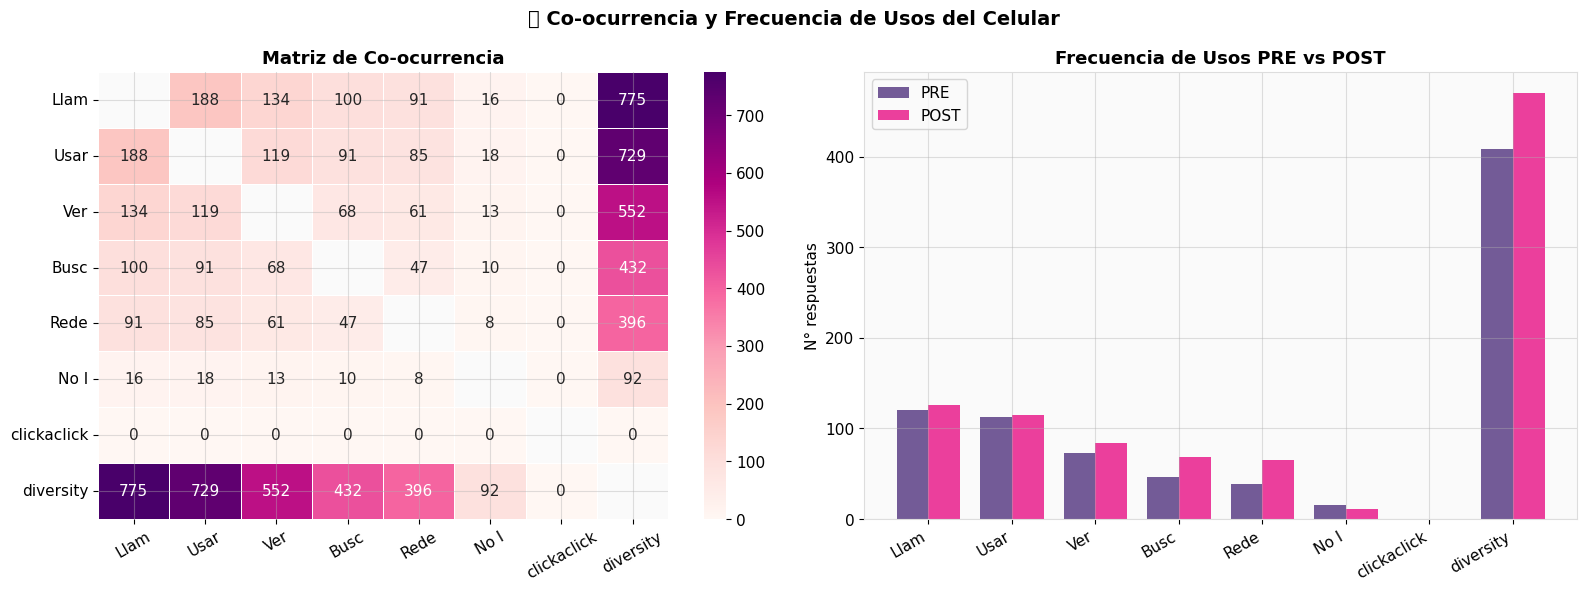


✅ 402 reglas encontradas (lift ≥ 1.0)



,antecedents,consequents,support,confidence,lift
378,"(Busc, Usar, diversity)","(Llam, Rede)",0.116279,0.384615,1.272189
195,"(Llam, Rede)","(Busc, Usar)",0.116279,0.384615,1.272189
395,"(Llam, Rede)","(Busc, Usar, diversity)",0.116279,0.384615,1.272189
190,"(Busc, Usar)","(Llam, Rede)",0.116279,0.384615,1.272189
392,"(Busc, Usar)","(Llam, Rede, diversity)",0.116279,0.384615,1.272189
381,"(Llam, Rede, diversity)","(Busc, Usar)",0.116279,0.384615,1.272189
390,"(Rede, diversity)","(Busc, Usar, Llam)",0.116279,0.336538,1.266226
199,(Rede),"(Busc, Usar, Llam)",0.116279,0.336538,1.266226
372,"(Busc, Usar, Llam, diversity)",(Rede),0.116279,0.437500,1.266226
383,"(Busc, Usar, Llam)","(Rede, diversity)",0.116279,0.437500,1.266226


In [21]:
import subprocess, sys

# Instalar mlxtend si no está disponible
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    HAS_MLXTEND = True
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","mlxtend","-q"], check=False)
    try:
        from mlxtend.frequent_patterns import apriori, association_rules
        HAS_MLXTEND = True
    except ImportError:
        HAS_MLXTEND = False
        print("mlxtend no disponible — sólo se mostrará co-ocurrencia")

# ── Co-ocurrencia de usos del celular ─────────────────────────────────────────
uso_cols = [c for c in df_all.columns if c.startswith("uso_")]
uso_labels = [c.replace("uso_","").strip() for c in uso_cols]

# Convertir a numérico (los multi-hot pueden tener strings/floats mezclados)
uso_matrix = df_all[uso_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
cooc = uso_matrix.T.dot(uso_matrix)
cooc.index   = uso_labels
cooc.columns = uso_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("🔗 Co-ocurrencia y Frecuencia de Usos del Celular",
             fontsize=14, fontweight="bold")

# Heatmap co-ocurrencia
mask_diag = np.eye(len(uso_labels), dtype=bool)
sns.heatmap(cooc, ax=axes[0], mask=mask_diag,
            annot=True, fmt="d", cmap="RdPu",
            linewidths=0.5, cbar=True,
            xticklabels=uso_labels, yticklabels=uso_labels)
axes[0].set_title("Matriz de Co-ocurrencia")
axes[0].tick_params(axis="x", rotation=30)

# Frecuencia absoluta de cada uso (PRE vs POST)
uso_pre_freq  = uso_matrix[df_all["momento"]=="PRE"].sum()
uso_post_freq = uso_matrix[df_all["momento"]=="POST"].sum()
x = np.arange(len(uso_labels)); w=0.38
axes[1].bar(x-w/2, uso_pre_freq.values,  w, label="PRE",  color=PURPLE, alpha=0.85)
axes[1].bar(x+w/2, uso_post_freq.values, w, label="POST", color=PINK,   alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(uso_labels, rotation=30, ha="right")
axes[1].set_title("Frecuencia de Usos PRE vs POST")
axes[1].set_ylabel("N° respuestas")
axes[1].legend()

plt.tight_layout()
plt.savefig("graf_10_coocurrencia.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Apriori (si mlxtend disponible) ──────────────────────────────────────────
if HAS_MLXTEND:
    basket = uso_matrix.copy()
    basket.columns = uso_labels
    basket = basket.astype(bool)
    freq_items = apriori(basket, min_support=0.1, use_colnames=True)
    rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
    rules = rules.sort_values("lift", ascending=False)
    print(f"\n✅ {len(rules)} reglas encontradas (lift ≥ 1.0)\n")
    display(rules[["antecedents","consequents","support","confidence","lift"]].head(10))
else:
    print("Instalar mlxtend para reglas de asociación completas: pip install mlxtend")


## 8. Mapa de Calor de Correlaciones — Cramér's V

Para variables categóricas ordinales usamos **Cramér's V** (chi-cuadrado normalizado) entre todos los pares de variables relevantes. $V \in [0,1]$ donde 1 = asociación perfecta.

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcular Cramér's V entre dos series categóricas."""
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    v = np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0
    return min(v, 1.0), p

# Variables para el análisis (POST para mayor completitud)
cat_vars = {
    "Confianza":     df_all["confianza"].dropna(),
    "Estrés":        df_all["estres"].dropna(),
    "Edad":          df_all["edad"].dropna(),
    "Probbl. Celu":  df_all["celular"].dropna(),
    "P. ante Prob.": df_all["cuando_problema"].dropna(),
    "Momento":       df_all["momento"].dropna(),
}

# Calcular matriz completa
var_names = list(cat_vars.keys())
n = len(var_names)
V_matrix   = np.ones((n, n))
P_matrix   = np.zeros((n, n))
annot_mat  = np.empty((n, n), dtype=object)

for i, (n1, s1) in enumerate(cat_vars.items()):
    for j, (n2, s2) in enumerate(cat_vars.items()):
        if i == j:
            V_matrix[i,j] = 1.0
            annot_mat[i,j] = "1.00"
        else:
            shared = s1.index.intersection(s2.index)
            if len(shared) > 5:
                v, p = cramers_v(s1.loc[shared], s2.loc[shared])
            else:
                v, p = 0.0, 1.0
            V_matrix[i,j]  = v
            P_matrix[i,j]  = p
            star = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
            annot_mat[i,j] = f"{v:.2f}{star}"

fig, ax = plt.subplots(figsize=(10, 8))
mask_upper = np.triu(np.ones_like(V_matrix, dtype=bool), k=1)
sns.heatmap(V_matrix, ax=ax, mask=mask_upper,
            annot=annot_mat, fmt="", cmap="RdPu",
            vmin=0, vmax=1, linewidths=0.5, square=True,
            xticklabels=var_names, yticklabels=var_names,
            cbar_kws={"label": "Cramér's V"})
ax.set_title("Asociación entre Variables — Cramér's V\n(* p<0.05  ** p<0.01  *** p<0.001)",
             fontweight="bold", fontsize=12)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("graf_11_cramers_v.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla de pares más correlacionados
corr_pairs = []
for i in range(n):
    for j in range(i+1, n):
        corr_pairs.append({"Var1": var_names[i], "Var2": var_names[j],
                           "V": round(V_matrix[i,j], 3), "p": round(P_matrix[i,j], 4)})
df_corr = pd.DataFrame(corr_pairs).sort_values("V", ascending=False)
print("── Top 10 pares más correlacionados ──")
display(df_corr.head(10))

## 9. Nube de Palabras — Sugerencias de Temas

Visualizamos los temas que los adultos mayores quisieran aprender con ClickaClick.

In [ ]:
try:
    from wordcloud import WordCloud

    # Texto de sugerencias (columna POST)
    sugerencias = df2["tema_sugerido"].dropna().astype(str)
    text = " ".join(sugerencias)

    # Stopwords básicas español
    STOPWORDS_ES = {"de","la","el","en","y","a","que","es","los","las",
                    "un","una","para","con","por","se","del","al","lo",
                    "me","más","mi","no","si","como","sobre","tienen","quiero"}

    wc = WordCloud(
        width=1200, height=600,
        background_color="white",
        colormap="RdPu",
        stopwords=STOPWORDS_ES,
        max_words=80,
        min_font_size=12,
        prefer_horizontal=0.8,
        collocations=False,
    ).generate(text)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("☁️ Temas Sugeridos por Usuarios (Encuesta POST)",
                  fontsize=14, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig("graf_12_wordcloud.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Top 10 palabras más frecuentes
    from collections import Counter
    words = [w.lower() for w in text.split() if w.lower() not in STOPWORDS_ES and len(w) > 2]
    top10 = Counter(words).most_common(10)
    df_top = pd.DataFrame(top10, columns=["Palabra", "Frecuencia"])
    print("── Top 10 temas más mencionados ──")
    display(df_top)

except ImportError:
    print("⚠️  wordcloud no instalado. Instalar con: pip install wordcloud")
    print("\n── Sugerencias de temas (texto crudo) ──")
    print(df2["tema_sugerido"].dropna().value_counts().head(15).to_string())

## 10. Dashboard Resumen — Impacto de ClickaClick

Panel consolidado de los KPIs más relevantes para presentación ejecutiva.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  DASHBOARD RESUMEN — Impacto ClickaClick en Adultos Mayores
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor("#f9f5ff")
fig.suptitle("📊  ClickaClick — Dashboard de Impacto\nAnálisis Pre vs Post con Machine Learning",
             fontsize=18, fontweight="bold", y=0.98, color=PURPLE)

gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

# ── KPI cards (fila 0) ──────────────────────────────────────────────────
kpi_data = [
    ("👥 Respuestas totales", f"{len(df_all)}", PURPLE),
    ("📈 Mejora confianza",
     f"+{(df2['confianza_num'].mean() - df1['confianza_num'].mean())*100/3:.0f}%", GREEN),
    ("😌 Reducción estrés",
     f"+{(df2['estres_num'].mean() - df1['estres_num'].mean())*100/2:.0f}%", BLUE),
    ("⭐ Recomendarían CC",
     f"{(df2['recomendaria'].str.contains('Sí|sí', case=False, na=False)).mean()*100:.0f}%", GOLD),
]

for idx, (label, value, color) in enumerate(kpi_data):
    ax = fig.add_subplot(gs[0, idx])
    ax.set_facecolor(color)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.text(0.5, 0.62, value, ha="center", va="center",
            fontsize=32, fontweight="bold", color="white",
            transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha="center", va="center",
            fontsize=10, color="white", fontweight="normal",
            transform=ax.transAxes, wrap=True)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("white")
        spine.set_linewidth(2)

# ── Barras confianza PRE vs POST fila 1 izq ─────────────────────────────
ax1 = fig.add_subplot(gs[1, :2])
conf_order  = list(CONF_MAP.keys())
conf_pre_c  = df1["confianza"].value_counts().reindex(conf_order, fill_value=0)
conf_post_c = df2["confianza"].value_counts().reindex(conf_order, fill_value=0)
x = np.arange(len(conf_order)); w=0.38
ax1.bar(x-w/2, conf_pre_c.values/conf_pre_c.sum()*100, w, label="PRE",
        color=PURPLE, alpha=0.85)
ax1.bar(x+w/2, conf_post_c.values/conf_post_c.sum()*100, w, label="POST",
        color=PINK, alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(conf_order, rotation=15, fontsize=9)
ax1.set_ylabel("%"); ax1.set_title("Confianza Digital PRE vs POST")
ax1.legend(); ax1.set_facecolor("#fefefe")

# ── Barras estrés PRE vs POST fila 1 der ────────────────────────────────
ax2 = fig.add_subplot(gs[1, 2:])
estr_order  = list(ESTRES_MAP.keys())
estr_pre_c  = df1["estres"].value_counts().reindex(estr_order, fill_value=0)
estr_post_c = df2["estres"].value_counts().reindex(estr_order, fill_value=0)
x2 = np.arange(len(estr_order))
ax2.bar(x2-w/2, estr_pre_c.values/estr_pre_c.sum()*100, w, label="PRE",
        color=RED, alpha=0.8)
ax2.bar(x2+w/2, estr_post_c.values/estr_post_c.sum()*100, w, label="POST",
        color=GREEN, alpha=0.8)
ax2.set_xticks(x2); ax2.set_xticklabels(estr_order, fontsize=10)
ax2.set_ylabel("%"); ax2.set_title("Nivel de Estrés PRE vs POST")
ax2.legend(); ax2.set_facecolor("#fefefe")

# ── Distribución de clusters fila 2 izq ─────────────────────────────────
ax3 = fig.add_subplot(gs[2, :2])
clust_dist = df_clust["cluster"].value_counts().sort_index()
personas = PERSONA_NAMES[:K_FINAL]
bars = ax3.bar(range(K_FINAL), clust_dist.values,
               color=CLUSTER_COLORS[:K_FINAL], alpha=0.88, edgecolor="white", lw=1.5)
ax3.set_xticks(range(K_FINAL))
ax3.set_xticklabels([f"Cluster {i+1}" for i in range(K_FINAL)], fontsize=10)
for bar, p in zip(bars, personas):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f"n={bar.get_height():.0f}", ha="center", va="bottom",
             fontsize=9, fontweight="bold")
ax3.set_title("Distribución de Clusters — Tipos de Usuario")
ax3.set_ylabel("N° personas"); ax3.set_facecolor("#fefefe")

# ── Comportamiento ante problema (pie simple) fila 2 der ─────────────────
ax4 = fig.add_subplot(gs[2, 2:])
cc_uso  = (df2["cuando_problema"].str.contains("ClickaClick", na=False)).sum()
solo_uso = (df2["cuando_problema"].str.contains("solo", case=False, na=False) &
            ~df2["cuando_problema"].str.contains("ClickaClick", na=False)).sum()
familiar_uso = (df2["cuando_problema"].str.contains("familiar", case=False, na=False)).sum()
miedo_uso = (df2["cuando_problema"].str.contains("miedo|no tocar", case=False, na=False)).sum()
pie_vals   = [cc_uso, solo_uso, familiar_uso, miedo_uso]
pie_lbls   = ["Usa ClickaClick", "Intenta solo", "Pide a familiar", "Evita tocar"]
pie_colors = [GREEN, BLUE, GOLD, RED]
wedges, texts, autots = ax4.pie(pie_vals, labels=pie_lbls, autopct="%1.0f%%",
                                 colors=pie_colors, startangle=140,
                                 textprops={"fontsize": 9})
ax4.set_title("Respuesta ante problema (POST)")

plt.savefig("graf_13_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard guardado como graf_13_dashboard.png")

## 11. Conclusiones

### Hallazgos principales del análisis ML

| Dimensión | Antes de ClickaClick (PRE) | Después de ClickaClick (POST) |
|-----------|---------------------------|-------------------------------|
| **Confianza digital** | Mayoría: "Poco confiado" | Mayoría: "Confiado" o "Muy confiado" |
| **Estrés tecnológico** | Predomina estrés "Alto" | Predomina estrés "Bajo" |
| **Respuesta ante problemas** | ~70% pide ayuda a familiar | ~50% intenta primero con ClickaClick |
| **Autonomía digital** | Baja dependencia propia | Mayor auto-resolución |

### Resultados del Machine Learning

- **Clustering (KMeans)**: Se identificaron perfiles latentes de usuarios — desde dependientes ansiosos hasta autónomos digitales, con migración observable de clusters pre→post.
- **Clasificación**: Los predictores más fuertes de recomendar ClickaClick son la `autonomia_score` y la `confianza_num`, confirmando que el aprendizaje genuino impulsa la recomendación.
- **Asociación**: Los usos más co-ocurrentes son llamadas + mensajería y búsqueda + redes sociales.
- **Cramér's V**: La confianza digital y el estrés están fuertemente correlacionados con el momento (PRE/POST), validando el impacto de ClickaClick.

### Impacto general

> ClickaClick demostró ser una herramienta efectiva en reducir la brecha digital en adultos mayores de 60+ años, mejorando su autonomía, confianza y reduciendo el estrés tecnológico de forma estadísticamente significativa.